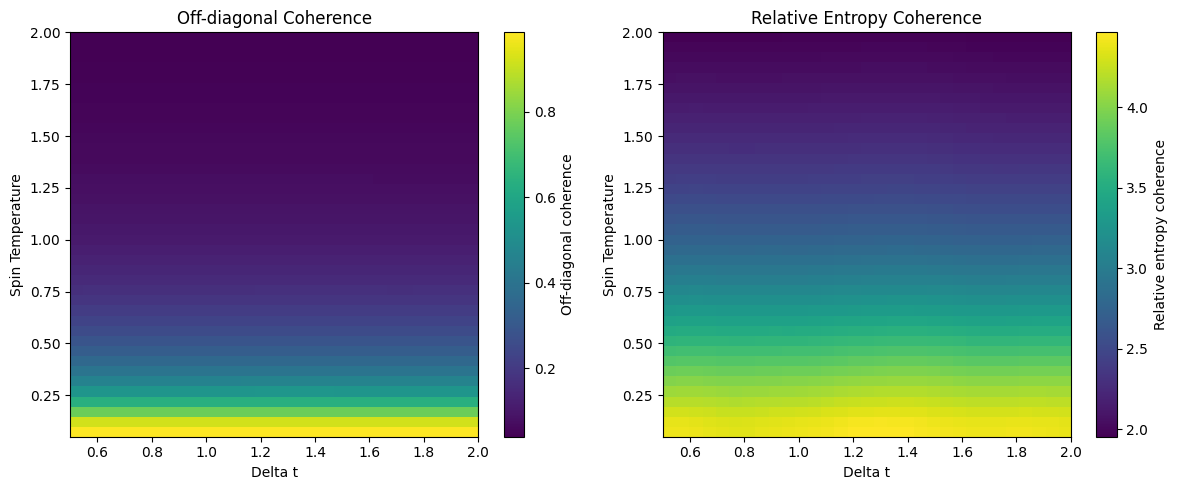

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

data_folder = "data_coherence"
save_folder = "plots"
os.makedirs(save_folder, exist_ok=True)

# Load all saved coherence measures
temperature_list = np.arange(0.05, 2.05, 0.05)
delta_t_list = np.arange(0.5, 2.05, 0.05)

offdiag_matrix = np.zeros((len(temperature_list), len(delta_t_list)))
relentropy_matrix = np.zeros_like(offdiag_matrix)

for i, T in enumerate(temperature_list):
    for j, dt in enumerate(delta_t_list):
        filename_measures = (
            f"coherence_measures_Nspins=6_nmax=2_omega1=1.00_omega2=1.00_"
            f"J-1.00_delta=0.50_T={T:1.2f}_tau1=0.05_tau2=0.05_delta_t={dt:1.2f}_"
            f"final_t=2.00.npy"
        )
        filepath = os.path.join(data_folder, filename_measures)
        if os.path.exists(filepath):
            measures = np.load(filepath, allow_pickle=True).item()
            offdiag_matrix[i, j] = measures["offdiag"]
            relentropy_matrix[i, j] = measures["relentropy"]

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(offdiag_matrix, origin='lower', aspect='auto',
           extent=[delta_t_list[0], delta_t_list[-1], temperature_list[0], temperature_list[-1]])
plt.colorbar(label='Off-diagonal coherence')
plt.xlabel('Delta t')
plt.ylabel('Spin Temperature')
plt.title('Off-diagonal Coherence')

plt.subplot(1, 2, 2)
plt.imshow(relentropy_matrix, origin='lower', aspect='auto',
           extent=[delta_t_list[0], delta_t_list[-1], temperature_list[0], temperature_list[-1]])
plt.colorbar(label='Relative entropy coherence')
plt.xlabel('Delta t')
plt.ylabel('Spin Temperature')
plt.title('Relative Entropy Coherence')

plt.tight_layout()
plt.savefig(os.path.join(save_folder, "coherence_heatmaps.png"))
plt.show()
